# 3주차. 자연어처리의 전환점, Attention

In [1]:
%pip install -q torch numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## 데이터

In [2]:
# 2주차와 같은 실제 번역 데이터를 다시 받는다 (Tatoeba, CC-BY 2.0, manythings.org/anki)
import re
import urllib.request
import zipfile
import io

url = "https://www.manythings.org/anki/kor-eng.zip"
req = urllib.request.Request(url, headers={
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept": "*/*",
})
raw = urllib.request.urlopen(req, timeout=30).read()

with zipfile.ZipFile(io.BytesIO(raw)) as zf:
    text = zf.read("kor.txt").decode("utf-8")

lines = text.strip().split("\n")
pairs = [(line.split("\t")[0], line.split("\t")[1]) for line in lines]
print(f"전체 문장 쌍: {len(pairs)}개")


전체 문장 쌍: 6394개


In [3]:
# 영어는 단어 단위, 한국어는 음절 단위(공백 포함)로 쪼갠다
def tok_en(s):
    return re.findall(r"[a-z']+|[.!?]", s.lower())


filtered = []
for en, ko in pairs:
    en_toks = tok_en(en)
    ko_chars = list(ko)
    if 2 <= len(en_toks) <= 8 and 2 <= len(ko_chars) <= 14:
        filtered.append((en, ko, en_toks, ko_chars))

print(f"필터 후: {len(filtered)}개")
for en, ko, _, _ in filtered[:5]:
    print(f"{en:20s} -> {ko}")


필터 후: 3211개
Go.                  -> 가.
Hi.                  -> 안녕.
Run!                 -> 뛰어!
Run!                 -> 도망가!
Run.                 -> 뛰어.


In [4]:
# 어휘를 만들고, 이후 Seq2Seq와 Attention 둘 다 같은 train/val/test를 쓴다
import collections
import random
import torch

random.seed(0)
torch.manual_seed(0)
random.shuffle(filtered)

PAD, SOS, EOS, UNK = 0, 1, 2, 3


def build_vocab(seqs):
    counter = collections.Counter(t for s in seqs for t in s)
    itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, _ in counter.most_common()]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos


en_stoi, en_itos = build_vocab([e for _, _, e, _ in filtered])
ko_stoi, ko_itos = build_vocab([k for _, _, _, k in filtered])
print(f"영어 어휘: {len(en_itos)}개, 한국어 어휘: {len(ko_itos)}개")


def encode(seq, stoi, add_eos):
    ids = [stoi.get(t, UNK) for t in seq]
    if add_eos:
        ids = ids + [EOS]
    return torch.tensor(ids, dtype=torch.long)


pair_data = [(encode(e, en_stoi, False), encode(k, ko_stoi, True), len(e)) for _, _, e, k in filtered]

n_val, n_test = 300, 300
val_pairs = [(s, t) for s, t, _ in pair_data[:n_val]]
test_pairs = [(s, t) for s, t, _ in pair_data[n_val:n_val + n_test]]
test_src_lens = [l for _, _, l in pair_data[n_val:n_val + n_test]]
train_pairs = [(s, t) for s, t, _ in pair_data[n_val + n_test:]]

print(f"train {len(train_pairs)}개 | val {len(val_pairs)}개 | test {len(test_pairs)}개")


영어 어휘: 1976개, 한국어 어휘: 833개
train 2611개 | val 300개 | test 300개


In [5]:
# 배치를 만드는 함수. Seq2Seq, Attention 둘 다 이 함수를 그대로 쓴다
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

embed_dim, hidden_size = 64, 128


def make_batch(items):
    src_list = [s for s, _ in items]
    tgt_list = [t for _, t in items]
    src_lens = torch.tensor([len(s) for s in src_list])
    order = src_lens.argsort(descending=True)
    src_list = [src_list[i] for i in order]
    tgt_list = [tgt_list[i] for i in order]
    src_lens = src_lens[order]
    src = pad_sequence(src_list, batch_first=True, padding_value=PAD)
    tgt_full = pad_sequence(tgt_list, batch_first=True, padding_value=PAD)
    sos_col = torch.full((len(tgt_list), 1), SOS, dtype=torch.long)
    tgt_in = torch.cat([sos_col, tgt_full[:, :-1]], dim=1)
    return src, src_lens, tgt_in, tgt_full


## Baseline: Attention 없는 Seq2Seq

In [6]:
# 2주차와 똑같은 구조. context를 인코더의 마지막 hidden state 하나로만 만든다
en_emb_base = nn.Embedding(len(en_itos), embed_dim, padding_idx=PAD)
ko_emb_base = nn.Embedding(len(ko_itos), embed_dim, padding_idx=PAD)
encoder_base = nn.LSTM(embed_dim, hidden_size, batch_first=True)
decoder_base = nn.LSTM(embed_dim, hidden_size, batch_first=True)
output_base = nn.Linear(hidden_size, len(ko_itos))

params_base = list(en_emb_base.parameters()) + list(ko_emb_base.parameters()) \
    + list(encoder_base.parameters()) + list(decoder_base.parameters()) + list(output_base.parameters())
opt_base = torch.optim.Adam(params_base, lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)


def run_epoch_base(dataset, train, bs=64):
    if train:
        random.shuffle(dataset)
    total_loss, total_tok, correct = 0, 0, 0
    for i in range(0, len(dataset), bs):
        batch = dataset[i:i + bs]
        src, src_lens, tgt_in, tgt_out = make_batch(batch)
        if train:
            opt_base.zero_grad()
        packed = pack_padded_sequence(en_emb_base(src), src_lens, batch_first=True)
        _, (h, c) = encoder_base(packed)          # 마지막 hidden state 하나만 씀
        dec_out, _ = decoder_base(ko_emb_base(tgt_in), (h, c))
        logits = output_base(dec_out)
        loss = criterion(logits.reshape(-1, len(ko_itos)), tgt_out.reshape(-1))
        if train:
            loss.backward()
            opt_base.step()
        mask = tgt_out != PAD
        correct += ((logits.argmax(-1) == tgt_out) & mask).sum().item()
        total_tok += mask.sum().item()
        total_loss += loss.item() * mask.sum().item()
    return total_loss / total_tok, correct / total_tok


base_history = []
for epoch in range(40):
    train_loss, train_acc = run_epoch_base(train_pairs, train=True)
    val_loss, val_acc = run_epoch_base(val_pairs, train=False)
    base_history.append((epoch, train_loss, train_acc, val_loss, val_acc))
    if epoch % 10 == 0 or epoch == 39:
        print(f"epoch {epoch:>2} | train loss {train_loss:.3f} acc {train_acc:.2f} "
              f"| val loss {val_loss:.3f} acc {val_acc:.2f}")

base_test_loss, base_test_acc = run_epoch_base(test_pairs, train=False)
print(f"Baseline Seq2Seq TEST 정확도 {base_test_acc:.2f}")


epoch  0 | train loss 5.443 acc 0.19 | val loss 4.302 acc 0.24


epoch 10 | train loss 2.815 acc 0.45 | val loss 2.960 acc 0.44


epoch 20 | train loss 2.138 acc 0.56 | val loss 2.627 acc 0.50


epoch 30 | train loss 1.605 acc 0.66 | val loss 2.539 acc 0.52


epoch 39 | train loss 1.211 acc 0.74 | val loss 2.568 acc 0.52
Baseline Seq2Seq TEST 정확도 0.52


## Attention 추가 (Query, Key, Value)

In [7]:
# 인코더: 마지막 hidden state만 내보내던 것을, 이제 매 시점 hidden state를 전부 내보낸다
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(len(en_itos), embed_dim, padding_idx=PAD)
        self.rnn = nn.LSTM(embed_dim, hidden_size, batch_first=True)

    def forward(self, src, src_lens):
        packed = pack_padded_sequence(self.emb(src), src_lens, batch_first=True)
        out, (h, c) = self.rnn(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)  # (B, S_src, H) 전 시점
        return out, (h, c)


In [8]:
# 디코더: 매 시점 Q를 만들고, 인코더의 모든 시점(K,V)과 비교해 context를 새로 만든다
class AttnDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(len(ko_itos), embed_dim, padding_idx=PAD)
        self.rnn = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.W_Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.out = nn.Linear(hidden_size * 2, len(ko_itos))

    def forward(self, tgt_in, h0c0, enc_out, src_mask):
        dec_out, hc = self.rnn(self.emb(tgt_in), h0c0)     # (B, S_tgt, H)

        Q = self.W_Q(dec_out)                               # 디코더 쪽 Query
        K = self.W_K(enc_out)                                # 인코더 쪽 Key
        V = self.W_V(enc_out)                                # 인코더 쪽 Value

        scores = Q @ K.transpose(-1, -2) / (hidden_size ** 0.5)  # scaled dot-product
        scores = scores.masked_fill(~src_mask.unsqueeze(1), float("-inf"))  # 패딩은 못 보게 막음
        alpha = torch.softmax(scores, dim=-1)                # attention weight
        context = alpha @ V                                   # 가중합

        combined = torch.cat([dec_out, context], dim=-1)
        logits = self.out(combined)
        return logits, alpha, hc


### 학습 (Teacher Forcing)

In [9]:
# 정답을 전부 알고 있으므로, 모든 디코더 시점을 한 번에 병렬로 계산한다
encoder = Encoder()
decoder = AttnDecoder()
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)


def run_epoch(dataset, train, bs=64):
    if train:
        random.shuffle(dataset)
    total_loss, total_tok, correct = 0, 0, 0
    for i in range(0, len(dataset), bs):
        batch = dataset[i:i + bs]
        src, src_lens, tgt_in, tgt_out = make_batch(batch)
        src_mask = src != PAD
        if train:
            optimizer.zero_grad()
        enc_out, (h, c) = encoder(src, src_lens)
        logits, alpha, _ = decoder(tgt_in, (h, c), enc_out, src_mask)
        loss = criterion(logits.reshape(-1, len(ko_itos)), tgt_out.reshape(-1))
        if train:
            loss.backward()
            optimizer.step()
        mask = tgt_out != PAD
        correct += ((logits.argmax(-1) == tgt_out) & mask).sum().item()
        total_tok += mask.sum().item()
        total_loss += loss.item() * mask.sum().item()
    return total_loss / total_tok, correct / total_tok


history = []
for epoch in range(40):
    train_loss, train_acc = run_epoch(train_pairs, train=True)
    val_loss, val_acc = run_epoch(val_pairs, train=False)
    history.append((epoch, train_loss, train_acc, val_loss, val_acc))
    if epoch % 5 == 0 or epoch == 39:
        print(f"epoch {epoch:>2} | train loss {train_loss:.3f} acc {train_acc:.2f} "
              f"| val loss {val_loss:.3f} acc {val_acc:.2f}")

attn_test_loss, attn_test_acc = run_epoch(test_pairs, train=False)
print(f"Attention Seq2Seq TEST 정확도 {attn_test_acc:.2f}")


epoch  0 | train loss 5.258 acc 0.21 | val loss 4.195 acc 0.28


epoch  5 | train loss 3.008 acc 0.43 | val loss 3.090 acc 0.42


epoch 10 | train loss 2.420 acc 0.51 | val loss 2.743 acc 0.48


epoch 15 | train loss 1.875 acc 0.59 | val loss 2.602 acc 0.51


epoch 20 | train loss 1.409 acc 0.68 | val loss 2.657 acc 0.53


epoch 25 | train loss 1.056 acc 0.76 | val loss 2.738 acc 0.54


epoch 30 | train loss 0.777 acc 0.82 | val loss 2.896 acc 0.54


epoch 35 | train loss 0.564 acc 0.88 | val loss 3.107 acc 0.54


epoch 39 | train loss 0.438 acc 0.91 | val loss 3.255 acc 0.54
Attention Seq2Seq TEST 정확도 0.53


### 추론 (Autoregressive)

In [10]:
# 정답이 없으므로 한 스텝씩 진행하고, 매 스텝 어느 입력 토큰을 얼마나 봤는지(attention weight)도 같이 남긴다
@torch.no_grad()
def translate_with_attention(en_toks, max_len=15):
    src = encode(en_toks, en_stoi, add_eos=False).unsqueeze(0)
    src_lens = torch.tensor([src.shape[1]])
    src_mask = src != PAD
    enc_out, (h, c) = encoder(src, src_lens)

    ys = [SOS]
    attn_rows = []
    for _ in range(max_len):
        y_in = torch.tensor([[ys[-1]]])
        logits, alpha, (h, c) = decoder(y_in, (h, c), enc_out, src_mask)
        nxt = logits[0, -1].argmax(-1).item()
        attn_rows.append(alpha[0, 0].tolist())
        if nxt == EOS:
            break
        ys.append(nxt)
    return ys[1:], attn_rows


for en, ko, en_toks, _ in filtered[n_val:n_val + 4]:
    pred_ids, attn_rows = translate_with_attention(en_toks)
    pred = "".join(ko_itos[i] for i in pred_ids)
    print(f"EN {en}")
    print(f"정답 {ko}")
    print(f"예측 {pred}")
    for step, tok_id in enumerate(pred_ids):
        row = attn_rows[step]
        best = max(range(len(en_toks)), key=lambda i: row[i])
        print(f"  step{step + 1} '{ko_itos[tok_id]}' -> 가장 많이 본 입력 단어: {en_toks[best]} ({row[best]:.2f})")
    print()


EN I'll speak with the teacher.
정답 선생님과 이야기하겠습니다.
예측 나는 뭐 뭐에 대해.
  step1 '나' -> 가장 많이 본 입력 단어: i'll (0.64)
  step2 '는' -> 가장 많이 본 입력 단어: . (0.91)
  step3 ' ' -> 가장 많이 본 입력 단어: . (1.00)
  step4 '뭐' -> 가장 많이 본 입력 단어: teacher (0.95)
  step5 ' ' -> 가장 많이 본 입력 단어: . (0.64)
  step6 '뭐' -> 가장 많이 본 입력 단어: teacher (0.68)
  step7 '에' -> 가장 많이 본 입력 단어: . (0.92)
  step8 ' ' -> 가장 많이 본 입력 단어: . (0.97)
  step9 '대' -> 가장 많이 본 입력 단어: the (0.75)
  step10 '해' -> 가장 많이 본 입력 단어: with (0.48)
  step11 '.' -> 가장 많이 본 입력 단어: . (0.94)

EN That made me nervous.
정답 저게 불안하게 만드네.
예측 그렇게 문제 하게 하게.
  step1 '그' -> 가장 많이 본 입력 단어: nervous (0.93)
  step2 '렇' -> 가장 많이 본 입력 단어: nervous (0.71)
  step3 '게' -> 가장 많이 본 입력 단어: . (0.97)
  step4 ' ' -> 가장 많이 본 입력 단어: . (0.97)
  step5 '문' -> 가장 많이 본 입력 단어: nervous (1.00)
  step6 '제' -> 가장 많이 본 입력 단어: nervous (0.53)
  step7 ' ' -> 가장 많이 본 입력 단어: . (0.96)
  step8 '하' -> 가장 많이 본 입력 단어: nervous (1.00)
  step9 '게' -> 가장 많이 본 입력 단어: . (0.60)
  step10 ' ' -> 가장 많이 본 입력 단어: . (1.00)
  st

## Seq2Seq vs Attention 비교

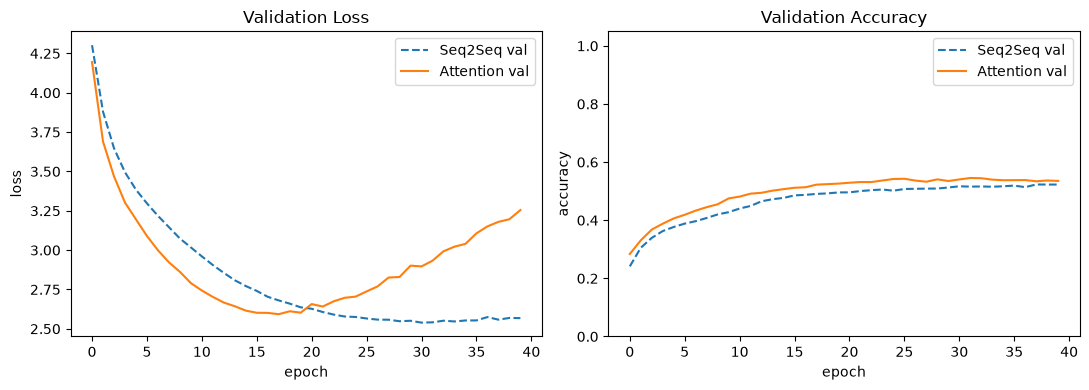

Seq2Seq   TEST 정확도 0.52
Attention TEST 정확도 0.53


In [11]:
# Seq2Seq와 Attention Seq2Seq의 학습 곡선, 테스트 정확도를 한 셀에서 같이 비교한다
base_epochs, base_tl, base_ta, base_vl, base_va = zip(*base_history)
attn_epochs, attn_tl, attn_ta, attn_vl, attn_va = zip(*history)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(base_epochs, base_vl, "--", label="Seq2Seq val")
axes[0].plot(attn_epochs, attn_vl, label="Attention val")
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(base_epochs, base_va, "--", label="Seq2Seq val")
axes[1].plot(attn_epochs, attn_va, label="Attention val")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Seq2Seq   TEST 정확도 {base_test_acc:.2f}")
print(f"Attention TEST 정확도 {attn_test_acc:.2f}")


In [12]:
# 2주차에서 봤던 고정 길이 병목이 Attention에서는 얼마나 완화되는지, 문장 길이별로 비교한다
def bucket_of(length):
    if length <= 4:
        return "짧음(2~4단어)"
    if length <= 6:
        return "중간(5~6단어)"
    return "긺(7~8단어)"


bucket_correct = collections.defaultdict(int)
bucket_total = collections.defaultdict(int)

for (src, tgt), src_len in zip(test_pairs, test_src_lens):
    with torch.no_grad():
        src_b = src.unsqueeze(0)
        enc_out, (h, c) = encoder(src_b, torch.tensor([src_len]))
        tgt_in = torch.cat([torch.tensor([[SOS]]), tgt[:-1].unsqueeze(0)], dim=1)
        src_mask = src_b != PAD
        logits, alpha, _ = decoder(tgt_in, (h, c), enc_out, src_mask)
        pred = logits.argmax(-1).squeeze(0)
    bucket = bucket_of(src_len)
    bucket_correct[bucket] += (pred == tgt).sum().item()
    bucket_total[bucket] += len(tgt)

print("Attention 모델의 문장 길이별 정확도")
for bucket in ["짧음(2~4단어)", "중간(5~6단어)", "긺(7~8단어)"]:
    acc = bucket_correct[bucket] / bucket_total[bucket]
    print(f"입력 길이 {bucket} | 정확도 {acc:.2f}")


Attention 모델의 문장 길이별 정확도
입력 길이 짧음(2~4단어) | 정확도 0.55
입력 길이 중간(5~6단어) | 정확도 0.53
입력 길이 긺(7~8단어) | 정확도 0.46
